In [31]:
# mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# change current working directory
import os
os.chdir('/content/drive/MyDrive/data')

In [33]:
# check we can see the dataset
os.path.isfile('pneumonia_raw.csv')

True

# Pneumonia Detection Project

## Intro

This notebook is an investigation into whether supervised learning could be used as an assistant to non-medical staff to make fast and reliable pneumonia diagnoses based solely on numerical measurements. This could potentially reduce or even eliminate the need for patients to wait for review by medically qualified clinicians. For the investigation, a pneumonia dataset has been prepared for testing across numerous supervised learning learning models and ensembles to see the strength of their predictive performance which will determine the potential of supervised learning as a healthcare assistant.

### Load and Clean The Data

In this section the dataset is being loaded and prepared as a clean dataset is more suitable for future investigations. To begin, a variety of packages are imported into the notebook that are specialised for specific tasks at hand, including each of the models and ensembles that will be utilised. Following this, the raw pneumonia dataset is loaded and a copy is created so that it can be cleaned separately whilst maintaining the original data. Any observations that were duplicates or missing any feature values were then dropped alongside the entire Patient ID column as it does not hold any data that is relevant to predicting pneumonia.

By using .describe(), a summary of the present data is displayed and is a useful tool to assess where any potential outliers may be. Through this, the outlier of 75 in X-ray brightness was identified (due to being much larger than the mean), as well as negative values in both max consolidation width and height which is not possible, hence their removal from the data.  

The pneumonia column was not present in the .describe() summary, meaning that a further examination was needed with .value_counts() which shows all the possible entries in that column, as well as the amount of times they appear. This showed that all pneumonia diagnosis entries were stored as yes/no strings rather than boolean values and that one of the values were stored as 'np'. This entry was removed rather than converted to a no to avoid making assumptions about what incorrect data entries should be. After this, the remaining yes/no pneumonia entries were replaced by 1/0 boolean values because to keep data columns as numerical values consistently.

In [34]:
# Importing the packages we use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
# Ensembles
from sklearn.ensemble import VotingClassifier, BaggingClassifier
# Ignore warnings to keep output clear
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Loading all the observations
observations = pd.read_csv('pneumonia_raw.csv')
# Make a copy of the Data that will be cleaned and then throughout the notebook
observations_clean = observations.copy()

# Delete any observations with missing feature values or duplicates
observations_clean = observations_clean.dropna()
observations_clean = observations_clean.drop_duplicates()
# Drop Patient_ID column as is irrelevant to problem
observations_clean = observations_clean.drop(columns='Patient_ID')

# See where any outliers may be in the data
print(observations_clean.describe())

# Remove extreme outliers
observations_clean = observations_clean[observations_clean['Xray_Brightness'] < 75]
observations_clean = observations_clean[observations_clean['Max_Consolidation_Width'] > 0]
observations_clean = observations_clean[observations_clean['Max_Consolidation_Height'] > 0]

# Check all possible Pnuemonia entries
print(observations_clean['Pneumonia'].value_counts())
# Only take entries that arent equal to np and then convert all entries to boolean values
observations_clean = observations_clean[observations_clean['Pneumonia'] != 'np']
observations_clean['Pneumonia'] = observations_clean['Pneumonia'].replace({'yes': 1, 'no': 0})

       Patient_Age        Male  Xray_Brightness  Xray_Contrast  \
count   583.000000  583.000000       583.000000     583.000000   
mean     44.746141    0.756432         3.298799       1.486106   
std      16.189833    0.429603         6.209522       2.808498   
min       4.000000    0.000000         0.400000       0.100000   
25%      33.000000    1.000000         0.800000       0.200000   
50%      45.000000    1.000000         1.000000       0.300000   
75%      58.000000    1.000000         2.600000       1.300000   
max      90.000000    1.000000        75.000000      19.700000   

       Silhouette_Sign  Max_Consolidation_Width  Max_Consolidation_Height  \
count       583.000000               583.000000                583.000000   
mean        290.576329                63.521441                 92.679245   
std         242.937989               455.691294                508.712618   
min          63.000000            -10000.000000             -10000.000000   
25%         175.5000

/tmp/ipython-input-373795693.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observations_clean['Pneumonia'] = observations_clean['Pneumonia'].replace({'yes': 1, 'no': 0})


### Check Clean Data
Here a summary of the clean dataset is provided  with a comparison between the amount of entries in the raw vs clean dataset as well as, the type of data present in each column. Furthermore, a graph has been created to visualise the difference between positive and negative pneumonia diagnosis's in the data.

------------------------------------------------- DATA OVERVIEW -------------------------------------------------
       Patient_Age        Male  Xray_Brightness  Xray_Contrast  \
count   579.000000  579.000000       579.000000     579.000000   
mean     44.734024    0.758204         3.188083       1.488946   
std      16.233005    0.428542         5.466698       2.815377   
min       4.000000    0.000000         0.400000       0.100000   
25%      33.000000    1.000000         0.800000       0.200000   
50%      45.000000    1.000000         1.000000       0.300000   
75%      58.000000    1.000000         2.600000       1.300000   
max      90.000000    1.000000        42.800000      19.700000   

       Silhouette_Sign  Max_Consolidation_Width  Max_Consolidation_Height  \
count       579.000000               579.000000                579.000000   
mean        290.975820                81.100173                110.393782   
std         243.677696               183.189732             

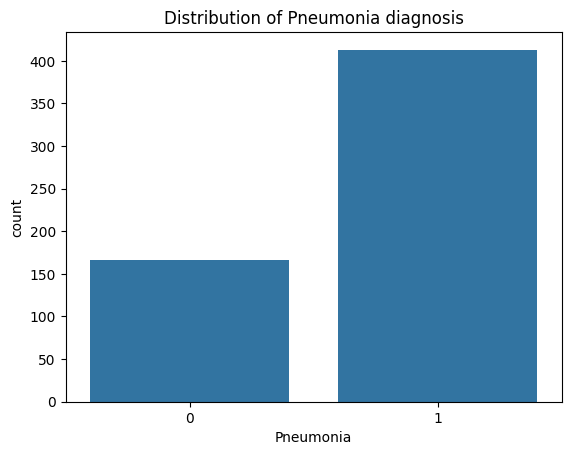

In [35]:
print('------------------------------------------------- DATA OVERVIEW -------------------------------------------------')
print(observations_clean.describe())
# Print summary of both raw and clean data to show differences
print('------------------------------------------------- RAW DATA -------------------------------------------------')
print(observations.info())
print('------------------------------------------------- CLEAN DATA -------------------------------------------------')
print(observations_clean.info())

# Visualize the distribution of the Pneumonia diagnosis
sns.countplot(x='Pneumonia', data=observations_clean)
plt.title('Distribution of Pneumonia diagnosis')
plt.show()

### Dataset preparation
The following code cell prepares the data using pneumonia as the target feature and splitting the data into examples and labels. Pneumonia is dropped from the data to be hidden from models so unbiased predictions can be made. The data is then shuffled and split into an 80/20 split using stratified sampling with the 80% being used as training and validation data and the 20% being reserved for testing data. A stratified k-Fold object is prepared for later use with each model containing a 5 fold split. Lastly, indices for each fold maintains the non_test_labels ratio in each fold and a preview for the data is shown.



In [36]:
# Set the name of the target feature
target_feature = 'Pneumonia'

# Split into examples and labels
examples = observations_clean.drop(columns=target_feature).to_numpy()
labels = observations_clean[target_feature].to_numpy()

# Shuffle and split into training/validation data (80%) and testing data (20%)
non_test_examples, test_examples, non_test_labels, test_labels = train_test_split(
    examples,
    labels,
    test_size=0.2,
    random_state=99,
    shuffle=True,
    stratify=labels
)

# Set up a StratifiedKFold object ready to figure out the indices of the example/label pairs in 5 different folds, using stratified sampling
skf = StratifiedKFold(n_splits=5)

# Generate the indices for each fold, maintining the label ratios seen in non_test_labels
indices = list(skf.split(non_test_examples, non_test_labels))

# Preview the data that will be used
print('--------------------------------------- DATA PREVIEW ---------------------------------------')
print(observations_clean)

--------------------------------------- DATA PREVIEW ---------------------------------------
     Patient_Age  Male  Xray_Brightness  Xray_Contrast  Silhouette_Sign  \
0             60   1.0              0.7            0.2              174   
1             18   1.0              1.3            0.7              316   
2             43   1.0              1.3            0.6              155   
3             38   1.0              1.0            0.3              216   
4             23   1.0              1.1            0.5              191   
..           ...   ...              ...            ...              ...   
579           18   1.0              0.9            0.3              300   
580           60   1.0              5.8            2.7              204   
581           50   1.0              0.7            0.2              188   
582           60   1.0              5.7            2.8              214   
583           65   0.0              0.7            0.1              187   

     M

## Models
In this section, multiple classification models have been tested with a range of hyperparameters to assess their resulting Area Under the Receiver Operating Characteristic Curve (AUC) scores with each change made. AUC score was chosen as the performance metric to test for because it determines how well a model can distinguish positive and negative cases. In addition, precision is calculated for each model which calculates when the model believes a case is positive, how often are they correct? Precision is catered towards positive cases due to the code pos_label=1.

### General Model Steps
In general, each model followed the same steps during creation with slight differences when concerning hyperparameter adjustments. This was done as an effort to maintain a consistent and well-developed recipe throughout the whole investigation.
These steps were:

1.   Create a pipeline combining the chosen model with a StandardScaler which adjusts feature values into similar ranges so that distribution has a mean of zero, and a standard deviation of 1.
2.   Set up the range of hyperparameter(s) values that will be tested.
3.   If testing multiple hyperparameters at once use a GridSearch to test all possible hyperparameter combinations (on the non-test data) and then print the best combo. If only testing one hyperparameter a for loop is used.
4.   Report on AUC scoring and the hyperparameter tuning setup to achieve the best result across the stratified 5 k-fold cross-validation setup.
5.   Retrain the model with the best hyperparameter setup using the test data.
6.    Calculate precision and plot the ROC curve across all models.









### Model 1 evaluation - Decision Tree model
The following code cell evaluates a Decision Tree model which has high interpretability, flexibility and low preprocessing needs which are well suited towards classification. The resulting AUC score is 71.1% which shows a strong performance when classifying between positive and negative cases.

Regarding hyperparameters, minimum samples split was used to control the number of splits in the tree and max depth was used to limit how deep the tree goes. The best combination of hyperparameters was a max depth of 5 and a minimum sample split of 35 which shows that although a higher depth was preferred, to achieve the best results the minimum number of samples was lower, showing that splitting less often is preferred.

Out of all the model’s positive predictions, they are correct 72% of the time which is shown by the precision score and suggests confidence in positive pneumonia predictions which is preferable for classification. The ROC curve score of 0.66 shows that the model is effective at predicting pneumonia cases but is likely to be falsely identifying some cases as positive due to the class imbalance or otherwise the score would be higher. This means that the True Negative Rate (TNR) is lower than expected.

Overall, the model provides strong results that tend towards positive pneumonia cases.


{'model__max_depth': 5, 'model__min_samples_split': 35}
AUC: 71.1%
Precision: 0.72


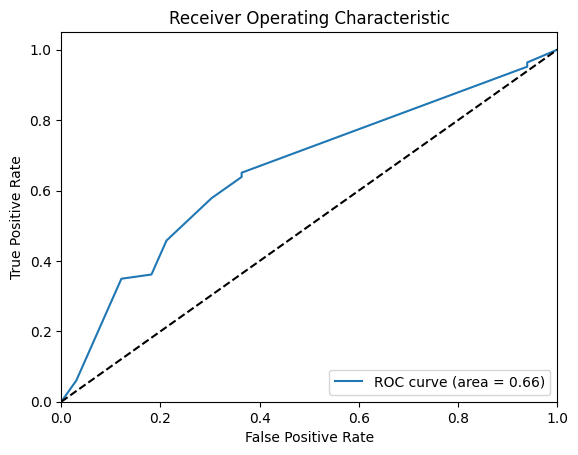

In [37]:
# Evaluate model 1 - Decision Tree model:

# Create a pipeline combining our model with our preprocessing step
dtc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=99))])
# set up all the hyperparameter values we want to test (all combinations are tested)
dtc_hyperparameters = {'model__min_samples_split':list(range(5, 101, 5)), 'model__max_depth':[1, 2, 3, 4, 5]}
# set up a search over all possible combinations of our hyperparameters
dtc_grid_search = GridSearchCV(dtc_pipeline, dtc_hyperparameters, cv=indices, scoring='roc_auc')
# run the grid search
dtc_grid_search.fit(non_test_examples, non_test_labels)

# Display info about the winning model
print(dtc_grid_search.best_params_)
print(f"AUC: {dtc_grid_search.best_score_ * 100:.1f}%")

# Now we've made our decisions about hyperparameters,
# we do a final re-train on all the non-testing data, and a final test on the testing data (and we STOP):

# grab the winning model with the winning hyperparameters (it's a pipeline again, as that's what we passed in)
dtc_winner = dtc_grid_search.best_estimator_
# Fit the pipeline to all our non-testing data
dtc_winner.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions for our testing examples
dtc_predictions = dtc_winner.predict(test_examples)

# Make predictions
y_pred = dtc_predictions
# Calculate precision, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = dtc_winner.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 2 evaluation - Random Forest model

The following code cell evaluates a Random Forest model which is an extension of the previous decision tree model by combining multiple at once as an effort to improve accuracy and reduce errors. The best resulting AUC score is 74.1% and supports the decision of using a random forest model to improve the accuracy in comparison to a singular decision tree.

Estimator values were chosen as the hyperparameter to adjust for this model as it controls how many decision trees are inside of the random forest model. The best results were seen when estimators were 95 which shows increasing the number of trees across a range between 5 to 100 shows a slight steady increase in AUC score with slight dips in-between but generally a large number of estimators is preferred.

The precision score is also an improvement over the decision tree with a score of 0.80 and shows less false positive predictions. Similarly, the improved ROC curve score of 0.79 shows that there is more balance in the predictions made.

Overall, the random forest model is an improvement over decision tree in all aspects and thus was a worthwhile investigation to make.




[0.69781145 0.74186308 0.64141414 0.70483683 0.77389277]
Estimator Value = 5, mean AUC = 71.2%
[0.75       0.74494949 0.66133558 0.72727273 0.76923077]
Estimator Value = 10, mean AUC = 73.1%
[0.79545455 0.73961841 0.62065095 0.72698135 0.78146853]
Estimator Value = 15, mean AUC = 73.3%
[0.7875982  0.73933782 0.62485971 0.71794872 0.79137529]
Estimator Value = 20, mean AUC = 73.2%
[0.79236813 0.7157688  0.6369248  0.71590909 0.79778555]
Estimator Value = 25, mean AUC = 73.2%
[0.79405163 0.70258137 0.64478114 0.73164336 0.78350816]
Estimator Value = 30, mean AUC = 73.1%
[0.78563412 0.70510662 0.63776655 0.7298951  0.78817016]
Estimator Value = 35, mean AUC = 72.9%
[0.78843996 0.69556678 0.64197531 0.72494172 0.79050117]
Estimator Value = 40, mean AUC = 72.8%
[0.79236813 0.70426487 0.63131313 0.72610723 0.79691142]
Estimator Value = 45, mean AUC = 73.0%
[0.80443322 0.71324355 0.63973064 0.72115385 0.80157343]
Estimator Value = 50, mean AUC = 73.6%
[0.79433221 0.70314254 0.62991021 0.71707

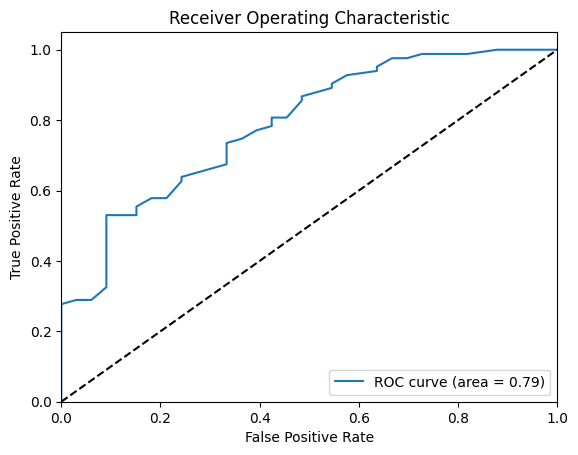

In [38]:
# Evaluate model 2 - Random Forest model:

# Define the range of hyperparameter values we're interested in
n_estimator_values = list(range(5, 101, 5))

for estimator in n_estimator_values:

  # Create a pipeline combining our model with our preprocessing step
  rfc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=99, n_estimators=estimator))])
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  auc_values = cross_val_score(rfc_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
  # Display all the accuracies,  one per fold
  print(auc_values)
  # Display the average accuracy
  print(f"Estimator Value = {estimator }, mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
rfc_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(random_state=99, n_estimators=95))])
# Fit the pipeline to our training data
rfc_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
rfc_final_predictions = rfc_final_pipeline.predict(test_examples)

# Make predictions
y_pred = rfc_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = rfc_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 3 evaluation - k-Nearest Neighbours model
The following code cell evaluates a k-Nearest Neighbours (KNN) model which offers a different approach to classification as it does not learn from the training set immediately but stores the entire dataset and then performs any computations at the time of classification. This is a different approach to any of the other models used and thus was an interesting model to investigate. The resulting AUC score is 67.9% which shows modest classification performance, particularly in comparison to the random forest and decision tree models which both scored higher.

The use of the number of neighbours as a hyperparameter was because it determines the sensitivity of the model as the number of neighbours directly impacts the predictions made. The best AUC score was achieved with neighbour values of both 45 and 85 which shows that a very small number of neighbours is not appropriate for this model but rather a medium to large size is.

In terms of precision, KNN provides similar results to the decision tree model with a score of 0.71 and even gets a higher ROC curve score of 0.68 despite having a lower AUC score than the decision tree model which shows that KNN has a stronger ability to distinguish between positive and negative cases.

Overall, the KNN model shows moderate performance for classification that is not up to the standards set by random forest and decision tree models despite having the slightly stronger ability to distinguish between healthy and unhealthy cases. This makes KNN not an appropriate choice as the best final model for classification.


[0.49635241 0.67789001 0.61672278 0.60897436 0.64219114]
Neighbor Value = 5, mean AUC = 60.8%
[0.55359147 0.65516274 0.61363636 0.61188811 0.66783217]
Neighbor Value = 10, mean AUC = 62.0%
[0.63860831 0.66750842 0.6369248  0.63782051 0.6520979 ]
Neighbor Value = 15, mean AUC = 64.7%
[0.64029181 0.66526375 0.62962963 0.62004662 0.67132867]
Neighbor Value = 20, mean AUC = 64.5%
[0.65291807 0.68742985 0.65095398 0.66899767 0.69784382]
Neighbor Value = 25, mean AUC = 67.2%
[0.6540404  0.66750842 0.64421998 0.66666667 0.67948718]
Neighbor Value = 30, mean AUC = 66.2%
[0.67592593 0.66554433 0.61447811 0.65909091 0.69871795]
Neighbor Value = 35, mean AUC = 66.3%
[0.70426487 0.66891134 0.61251403 0.66462704 0.68851981]
Neighbor Value = 40, mean AUC = 66.8%
[0.70089787 0.68518519 0.61756453 0.68210956 0.70745921]
Neighbor Value = 45, mean AUC = 67.9%
[0.6882716  0.66638608 0.6010101  0.68968531 0.70075758]
Neighbor Value = 50, mean AUC = 66.9%
[0.67845118 0.65347924 0.59792368 0.69755245 0.7109

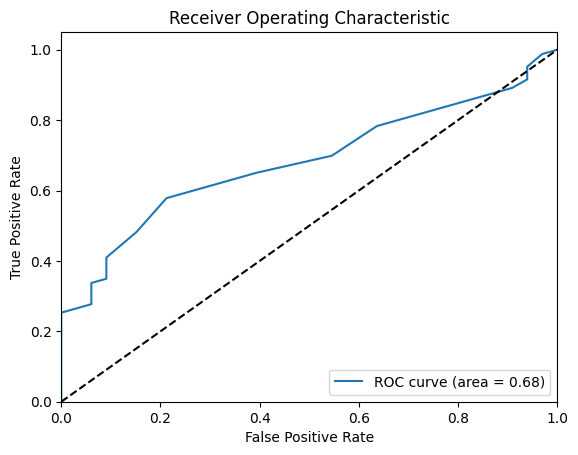

In [39]:
# Evaluate model 3 - k-Nearest Neighbours model:

# Define the range of hyperparameter values we're interested in
n_neighbor_values = list(range(5, 101, 5))

for neighbor in n_neighbor_values:

  # Create a pipeline combining our model with our preprocessing step
  knc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=neighbor))])
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  auc_values = cross_val_score(knc_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
  # Display all the accuracies,  one per fold
  print(auc_values)
  # Display the average accuracy
  print(f"Neighbor Value = {neighbor}, mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
knc_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=45))]) # multiple at same auc
# Fit the pipeline to our training data
knc_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
knc_final_predictions = knc_final_pipeline.predict(test_examples)

# Make predictions
y_pred = knc_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = knc_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 4 evaluation - Naive Bayes model
The following code cell evaluates a Naive Bayes model which is predicts the category of a data point using probability and assumes that all features are independent of each other. The resulting AUC score is 73.1% which shows strong classification performance and shows that this model’s approach is valid due to results in a close range with the random forest model.

This model was tuned with no hyperparameters because the Naive Bayes model has no meaningful hyperparameters available for the problem.

A strong precision score of 0.97 shows that when the model predicts pneumonia, it is right 97% of the time and shows that there is a low false positive rate. Meanwhile a ROC curve score of 0.70 shows even though the model is reliable when making pneumonia predictions, low healthy case precision brings the models reliability down to a level more in-line with the other models.

Overall, the Naive Bayes model is a strong choice of model for classification, particularly due to the high precision score and comparable AUC/ROC curve scores to other models, which shows the models reliability.



[0.78843996 0.69640853 0.63748597 0.72231935 0.81002331]
Mean AUC = 73.1%
Precision: 0.97


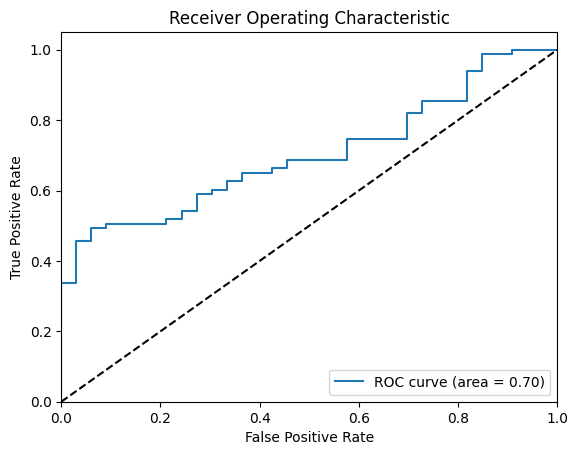

In [40]:
# Evaluate model 4 - Naive Bayes model:

# Create a pipeline combining our model with our preprocessing step
gnb_pipeline = Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
auc_values = cross_val_score(gnb_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
# Display all the accuracies,  one per fold
print(auc_values)
# Display the average accuracy
print(f"Mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
gnb_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())])
# Fit the pipeline to our training data
gnb_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
gnb_final_predictions = gnb_final_pipeline.predict(test_examples)

# Make predictions
y_pred = gnb_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = gnb_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 5 evaluation - Logistic Regression model

The following code cell evaluates a Logistic Regression model which predicts the probability that an input belongs to a certain class. The use of a Stochastic Gradient Descent (SGD) logistic regression model specifically is for its versatility, especially when large datasets are involved. The resulting AUC score is 70.2% and demonstrates a decent ability to classify pneumonia cases.

Hyperparameter tuning was carried out with the use of maximum iterations which is the maximum number of search steps to take whilst looking for the best model parameters. The best scoring number of iterations was 10 with results declining with further increase of iterations. This shows that only a limited number of iterations were required to optimise performance and beyond that reduces classification performance.

The precision of 0.73 shows moderate results when predicting pneumonia and 0.59 ROC curve score shows a weak ability to distinguish between positive and negative cases.

Overall, the Logistic Regression model shows signs of moderate performance yet is held back by a limited ROC score making it not the most suitable choice for pneumonia classification.





[0.72390572 0.68967452 0.64870932 0.68939394 0.75641026]
Iter Value = 10, mean AUC = 70.2%
[0.75196409 0.58810325 0.57519641 0.70512821 0.6958042 ]
Iter Value = 50, mean AUC = 66.3%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 100, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 150, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 200, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 350, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 500, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 1000, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 1500, mean AUC = 67.1%
[0.64927048 0.69472503 0.62345679 0.70512821 0.68065268]
Iter Value = 2000, mean AUC = 67.1%
Precision: 0.73


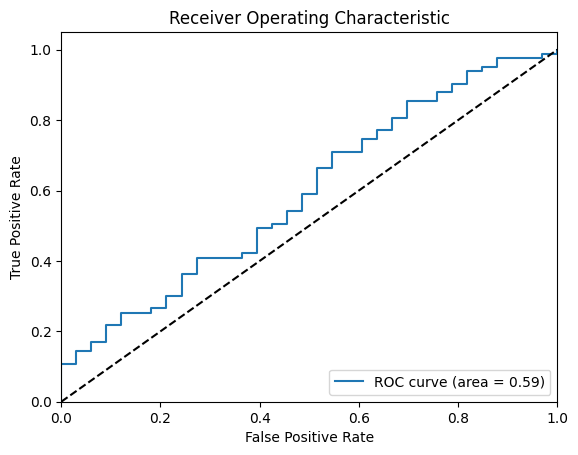

In [41]:
# Evaluate model 5 - Logistic Regression model:

# Define the range of hyperparameter values we're interested in
max_iters = [10, 50, 100, 150, 200, 350, 500, 1000, 1500, 2000]

for iter in max_iters:

  # Create a pipeline combining our model with our preprocessing step
  sgdc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99, max_iter=iter, loss='log_loss'))])
  # calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
  auc_values = cross_val_score(sgdc_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
  # Display all the accuracies,  one per fold
  print(auc_values)
  # Display the average accuracy
  print(f"Iter Value = {iter}, mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
sgdc_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SGDClassifier(random_state=99, max_iter=10, loss='log_loss'))])
# Fit the pipeline to our training data
sgdc_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
sgdc_final_predictions = sgdc_final_pipeline.predict(test_examples)

# Make predictions
y_pred = sgdc_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = sgdc_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 6 evaluation - Support Vector Classifier model

The following code cell evaluates a Support Vector Classifier model that aims to maximize the margin between the decision boundary and the nearest points of data from any class. The resulting AUC score is 68.6% which is generally poorer in comparison to previously covered models.

Both gamma and C were adjusted during hyperparameter tuning with the best results being achieved with a C value of 100 and a gamma value of 0.01. The high C value shows that the model prioritises minimising classification error where possible. On the other end of the spectrum, the low gamma score aims to influence the behaviour of the decision boundary in a minimal manner which reduces the complexity. These scores being at the maximum and minimum representative ends of the hyperparameter ranges shows that strong classification skills and relaxed decision boundaries is preferred with this specific dataset and model.

A precision score of 0.72 and ROC score of 0.66 shows that whilst pneumonia predictions are made with more confidence, bias is present towards pneumonia which is represented by the lower ROC score.

Overall, the SVC model has weak distinctive ability between positive and negative cases and because of this is outperformed across multiple metrics by other models.



{'model__C': 100, 'model__gamma': 0.01}
AUC: 68.6%
Precision: 0.72


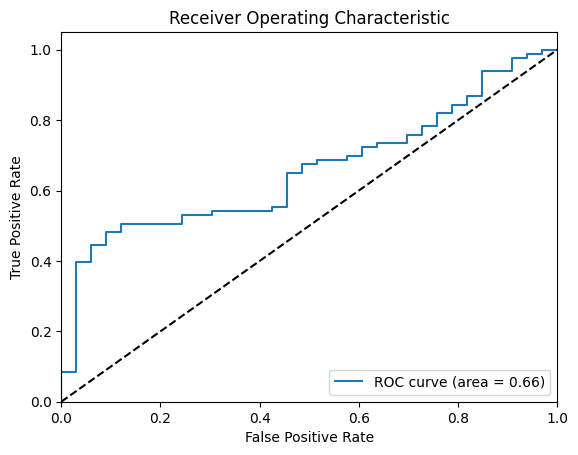

In [42]:
# Evaluate model 6 - Support Vector Classifier model:

# Create a pipeline combining our model with our preprocessing step
svc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', SVC(probability=True))])
# set up all the hyperparameter values we want to test (all combinations are tested)
svc_hyperparameters = {'model__gamma':[x / 100.0 for x in range(1, 11, 1)], 'model__C':[0.01, 0.1, 1, 10, 100]}
# set up a search over all possible combinations of our hyperparameters
svc_grid_search = GridSearchCV(svc_pipeline, svc_hyperparameters, cv=indices, scoring='roc_auc')
# run the grid search
svc_grid_search.fit(non_test_examples, non_test_labels)

# Display info about the winning model
print(svc_grid_search.best_params_)
print(f"AUC: {svc_grid_search.best_score_ * 100:.1f}%")

# Now we've made our decisions about hyperparameters, and because we're only asked to consider SVMs (no other models),
# we do a final re-train on all the non-testing data, and a final test on the testing data (and we STOP):

# grab the winning model with the winning hyperparameters (it's a pipeline again, as that's what we passed in)
svc_winner = svc_grid_search.best_estimator_
# Fit the pipeline to all our non-testing data
svc_winner.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions for our testing examples
svc_predictions = svc_winner.predict(test_examples)

# Make predictions
y_pred = svc_predictions
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = svc_winner.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Model 7 evaluation - Artificial Neural Network model

The following code cell evaluates an Artificial Neural Network (ANN) model which uses artificial neurons to mimic brain behaviour that analyses data, identifies patterns and makes predictions meaning that ANN is a good model choice for pneumonia classification. The resulting AUC score is 74.5% which is the strongest result provided by individual models, showing a strong ability to determine between healthy and pneumonia cases.

One of the tuned hyperparameters was hidden layers which is a layer (or layers) of artificial neurons that pass data amongst themselves. The best result was achieved with a singular layer of 20 neurons and shows that only one layer is required to provide the best results and 20 neurons suggests only a moderate number of neurons is required.
The other hyperparameter used was maximum iterations again with the optimum value being 350 iterations showing that an extremely large number of iterations is not required to train this model.

The precision score of 0.73 and ROC curve score of 0.70 shows similar scores as previous models which indicates solid performance.

Overall, the ANN model shows strong performance, making it one of the top choices for individual models for classification.




{'model__hidden_layer_sizes': (20,), 'model__max_iter': 350}
AUC: 74.5%
Precision: 0.73


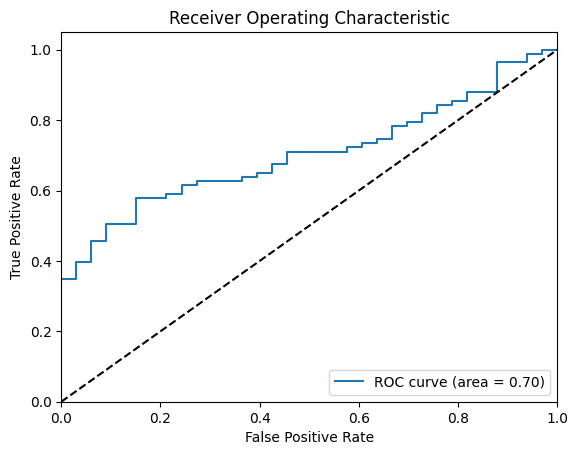

In [43]:
# Evaluate model 7 - Artificial Neural Network model:

# Create a pipeline combining our model with our preprocessing step
mlpc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(random_state=99))])
# set up all the hyperparameter values we want to test (all combinations are tested)
mlpc_hyperparameters = {'model__hidden_layer_sizes':[(10,), (20,), (20,10)], 'model__max_iter':[350, 500, 1000]}
# set up a search over all possible combinations of our hyperparameters
mlpc_grid_search = GridSearchCV(mlpc_pipeline, mlpc_hyperparameters, cv=indices, scoring='roc_auc')
# run the grid search
mlpc_grid_search.fit(non_test_examples, non_test_labels)

# Display info about the winning model
print(mlpc_grid_search.best_params_)
# print(grid_search.best_score_)
print(f"AUC: {mlpc_grid_search.best_score_ * 100:.1f}%")

# Now we've made our decisions about hyperparameters, and because we're only asked to consider SVMs (no other models),
# we do a final re-train on all the non-testing data, and a final test on the testing data (and we STOP):

# grab the winning model with the winning hyperparameters (it's a pipeline again, as that's what we passed in)
mlpc_winner = mlpc_grid_search.best_estimator_
# Fit the pipeline to all our non-testing data
mlpc_winner.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions for our testing examples
mlpc_predictions = mlpc_winner.predict(test_examples)

# Make predictions
y_pred = mlpc_predictions
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = mlpc_winner.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Ensembles
Ensembles are good next step to investigate because they can be used to combine multiple models with the aim of getting better and more accurate results.

### General Ensemble steps
To create ensembles the same process was followed as the general model steps with the releveant models being placed into a pipeline.

### Ensemble 1 - Voting Ensemble Evaluation
In the individual model section, the three most balanced models were Random Forest, Naive Bayes and Artificial Neural Network and thus were the best choice for use in a Voting Ensemble. A voting ensemble was chosen as an ensemble to evaluate because it gains experience by training on a collection of models and leverages them to make a single strongest prediction. Each model was inserted into the ensemble using their best hyperparameter setup as seen in previous individual model testing.

The resulting AUC score of 75.0% demonstrates the strongest distinguishability than any of the previous models. This shows that combining models can improve the general AUC score and also leaves space for improvements in other aspects.

The ensemble reaches high precision score with a score of 0.92 which showcases that when pneumonia is predicted, the ensemble is correct the majority of the time. Furthermore, a ROC curve score of 0.77 shows a decent ability at deciding between healthy and pneumonia cases which gives more merit to the strong precision score.

The voting ensemble shows that the strongest performance, that is well balanced across the assessed metrics, is achieved by utilizing multiple strongly performing models to gain input from multiple sources that is combined into a single strongly performing ensemble output.


[0.82659933 0.71212121 0.62289562 0.78263403 0.80652681]
Mean AUC = 75.0%
Precision: 0.92


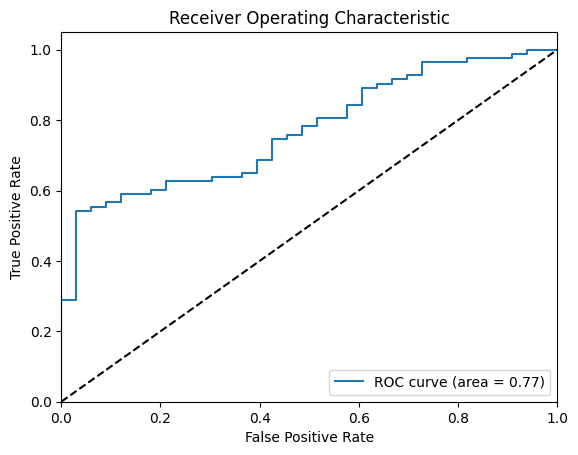

In [44]:
# Evaluate Ensemble 1 - Voting Ensemble:

# set the details of the classifiers we want to use (all using their default hyperparameters)
rf_model = RandomForestClassifier(n_estimators=95, random_state=99)
nb_model = GaussianNB()
ann_model = MLPClassifier(hidden_layer_sizes=(20,), max_iter=350, random_state=99)

# Create a pipeline combining our models with our preprocessing step
vc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', VotingClassifier(estimators=[('rf_model', rf_model), ('nb_model', nb_model), ('ann_model', ann_model)], voting='soft'))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
auc_values = cross_val_score(vc_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
# Display all the accuracies,  one per fold
print(auc_values)
# Display the average accuracy
print(f"Mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our models with our preprocessing step
vc_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', VotingClassifier(estimators=[('rf_model', rf_model), ('nb_model', nb_model), ('ann_model', ann_model)], voting='soft'))])
# Fit the pipeline to our training data
vc_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
vc_final_predictions = vc_final_pipeline.predict(test_examples)

# Make predictions
y_pred = vc_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = vc_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Ensemble 2 - Bagging Ensemble Evaluation
Here a bagging ensemble was evaluated with the use of one of the best performing individual models the Naive Bayes model. Bagging was chosen as an ensemble because it aims to increase stability and accuracy of models and therefore, improvements should be seen over the regular use of Naive Bayes. Although ANN and the decision tree classifier (DTC) were found to be other strong models during individual model testing, upon use with a bagging ensemble, these models were found to take significantly longer and have slightly lower AUC scores making their use not worthwhile.

The provided AUC score was 72.7% and shows comparable results to other bagging ensemble setups. However, this is a decrease in comparison to what was seen in regular NB testing which shows that the use of a bagging ensemble had a negative impact on the NB model's ability to distinguish between positive and negative cases.

With the bagging ensemble precision score of 0.97 the ensembles precision is identical to the individual NB model. Furthermore, the ROC score is also unchanged from the regular NB model with the same score of 0.70.

Overall, the bagging ensemble does not see a change in results from the regular use of Naive Bayes making it unnecessary in many aspects and even sees a decrease in AUC score which shows that the use of the individual NB model would be a more appropriate choice.



[0.78114478 0.69079686 0.64478114 0.72348485 0.79312354]
Mean AUC = 72.7%
Precision: 0.97


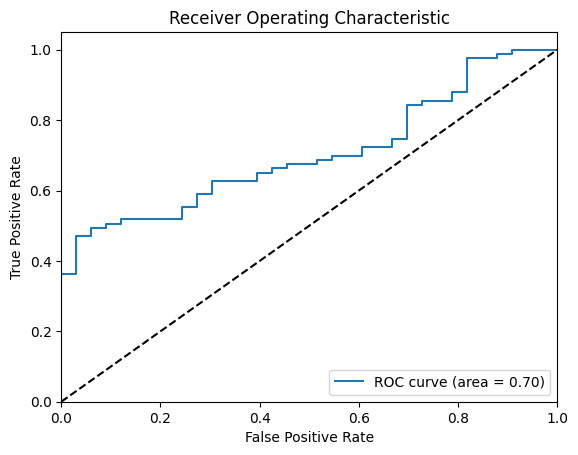

In [45]:
# Evaluate Ensemble 2 - Bagging Ensemble:

# set the details of the classifiers we want to use (all using their default hyperparameters)
model_nb = GaussianNB()

# Create a pipeline combining our model with our preprocessing step
bc_pipeline = Pipeline([('scaler', StandardScaler()), ('model', BaggingClassifier(model_nb, n_estimators=100, random_state=99))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
auc_values = cross_val_score(bc_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
# Display all the accuracies,  one per fold
print(auc_values)
# Display the average accuracy
print(f"Mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
bc_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', BaggingClassifier(model_nb, n_estimators=100, random_state=99))])
# Fit the pipeline to our training data
bc_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
bc_final_predictions = bc_final_pipeline.predict(test_examples)

# Make predictions
y_pred = bc_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = bc_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

### Ensemble 3 - Random Subspaces Ensemble Evaluation
For the random subspaces ensemble, the random forest classifier, with its best hyperparameter setup, was chosen as it scored the highest AUC score across all random subspaces testing that maintained scores in other metrics in line with previous results. Random subspaces were chosen as an ensemble to investigate as randomly sampling the features in your examples when training each model can be an effective way to build effective ensembles. Random subspaces works by adjusting a Bagging Classifier by disabling bootstrap with a maximum features number of six.

The resulting AUC score of 74.4% is one of the highest seen across all the models and demonstrates a strong ability to distinguish between healthy and pneumonia X-ray scans.

The precision score of 0.77 and ROC curve score of 0.76 show balanced model performance, with scores across both metrics comparable to similar scores seen previously covered models and ensembles.

Overall, the random subspaces ensemble provides strong results that are well balanced across all metrics which makes it one of the best seen performing models, despite taking slightly longer to provide results.








[0.81144781 0.74017957 0.64814815 0.72843823 0.79254079]
Mean AUC = 74.4%
Precision: 0.77


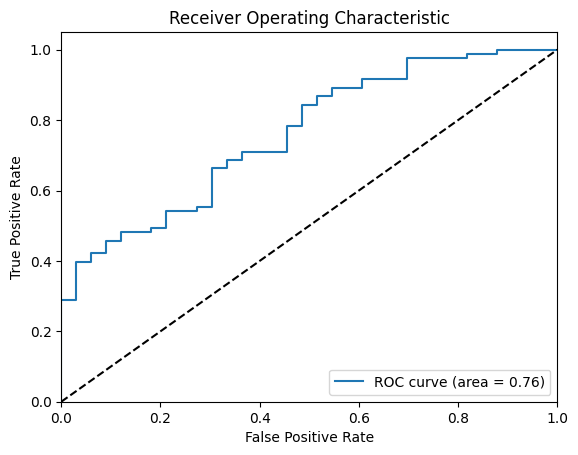

In [46]:
# Evaluate Ensemble 3 - Random Subspaces Ensemble:

# set the details of the classifiers we want to use (all using their default hyperparameters)
model_dt = RandomForestClassifier(n_estimators=95, random_state=99)

# Create a pipeline combining our model with our preprocessing step
rs_pipeline = Pipeline([('scaler', StandardScaler()), ('model', BaggingClassifier(model_dt, n_estimators=100, random_state=99, bootstrap=False, max_features=6))])
# calculate the accuracy scores for each of the 5 folds, using k-fold cross validation, and return them in an array
auc_values = cross_val_score(rs_pipeline, non_test_examples, non_test_labels, cv=indices, scoring='roc_auc')
# Display all the accuracies,  one per fold
print(auc_values)
# Display the average accuracy
print(f"Mean AUC = {np.mean(auc_values) * 100:.1f}%")

# Create a pipeline combining our model with our preprocessing step
rs_final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', BaggingClassifier(model_dt, n_estimators=100, random_state=99, bootstrap=False, max_features=6))])
# Fit the pipeline to our training data
rs_final_pipeline.fit(non_test_examples, non_test_labels)
# Use the pipeline to generate predictions on our testing examples
rs_final_predictions = rs_final_pipeline.predict(test_examples)

# Make predictions
y_pred = rs_final_pipeline.predict(test_examples)
# Calculate precision and recall, specifying the positive class (pos_label=1 for Positive)
precision = precision_score(test_labels, y_pred, pos_label=1)
print(f"Precision: {precision:.2f}")

# Generate predicted probabilities for the positive class
y_prob = rs_final_pipeline.predict_proba(test_examples)[:, 1]
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(test_labels, y_prob)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

## Evaluation
This investigation used a stratified, 5-fold cross-validation, shuffled 80/20 train/test holdout split to evaluate the following models: Decision Tree, Random Forest, k-Nearest Neighbours, Naive Bayes, Logistic Regression, Support Vector and Artificial Neural Network. Alongside these models the following ensembles were investigated: Voting, Bagging and Random Subspaces. 

It found that the Voting ensemble gave the strongest performance with an AUC score of 75%. with a precision of 92% and ROC score of 77%. These results show that the Voting ensemble has the best expected future performance on new sets of data and shows that it is possible to achieve a balanced classification model for pneumonia classification. Throughout development all models and ensembles followed a consistent and well-developed recipe alongside five-fold stratified cross validation using an 80/20 split. The voting ensemble results provides an estimate of expected future performance with the performance metrics shown.
